### **About Data**

# 6CS012 - Artificial Intelligence and Machine Learning

## Text Classification using RNN

### Name: Raj Prajapati <br> Uni ID: 2418626

The dataset consists Reviews and Ratings of hotels from TripAdvisor. It is used for sentiment analysis to classify the review in three categories: Positve, Neutral and Negative

In [ ]:
#mount google drive
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import pandas as pd
#load the dataset
data = pd.read_csv("/content/drive/MyDrive/AI_Final_Coursework/tripadvisor_hotel_reviews.csv")

In [46]:
#Importing libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from wordcloud import WordCloud

!pip install contractions
import contractions

#1. Data Understanding, Analysis and Cleaning

### **Data Understanding**

In [ ]:
data.info() #checking the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


In [ ]:
data.head() #showing first 5 data

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [ ]:
data.tail() #showing last 5 data

,Review,Rating
20486,"best kept secret 3rd time staying charm, not 5...",5
20487,great location price view hotel great quick pl...,4
20488,"ok just looks nice modern outside, desk staff ...",2
20489,hotel theft ruined vacation hotel opened sept ...,1
20490,"people talking, ca n't believe excellent ratin...",2


from matplotlib import pyplot as plt
_df_0['Rating'].plot(kind='hist', bins=20, title='Rating')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('Review').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Rating'].plot(kind='line', figsize=(8, 4), title='Rating')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_3['Review'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_3, x='Rating', y='Review', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
data.isnull().any() #checking for null values

Review    False
Rating    False
dtype: bool

Here we can see that our csv file has 3 columns and Rating is the dependent varibale and there no any null value

In [ ]:
data['Rating'].value_counts() #checking the rating distribution

Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64

In [ ]:
#mapping the values of rating
data['Sentiment'] = data['Rating'].apply(lambda x:'negative' if x in [1,2] else ('neutral' if x==3 else 'positive'))

### Data Analysis


In [ ]:
data.head()

,Review,Rating,Sentiment
0,nice hotel expensive parking got good deal sta...,4,positive
1,ok nothing special charge diamond member hilto...,2,negative
2,nice rooms not 4* experience hotel monaco seat...,3,neutral
3,"unique, great stay, wonderful time hotel monac...",5,positive
4,"great stay great stay, went seahawk game aweso...",5,positive


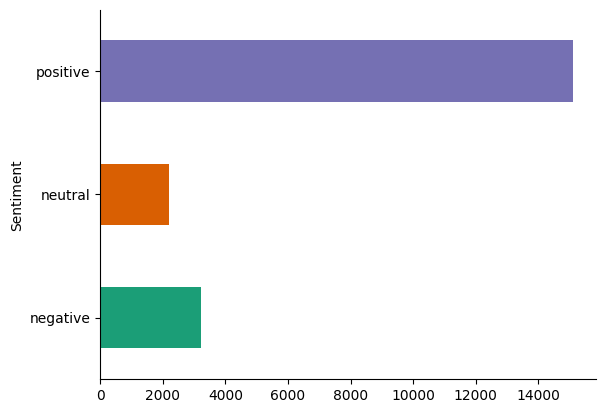

In [ ]:
data.groupby('Sentiment').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

Now we can see that column sentiment is added as per the classification.

### **Data Cleaning**

In [ ]:

def clean_data(text):
    text = re.sub(r'\d+', '', text)  # Remove all numbers from the text using regex, which can include numerical values.
    text = re.sub(r"(?i)\b(\w+)\s+n't\b", r"\1n't", text) # converting the words like  "do n't" to "don't"
    text = contractions.fix(text)  # Expand common English contractions, e.g., "can't" becomes "cannot".
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation from the text, leaving only letters and whitespace.
    text = text.lower()      # Convert all characters in the text to lowercase to standardize the data.
    return text
data['Cleaned_review'] = data['Review'].apply(clean_data) # Apply the cleaning function to each review in the dataset to create a new column with cleaned reviews.

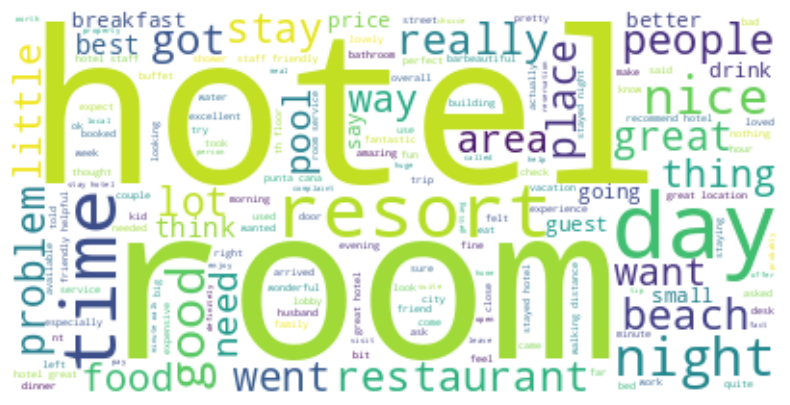

In [47]:

# Assuming 'Cleaned_review' is a column with text data
text = " ".join(review for review in data['Cleaned_review'])

# Create and generate a word cloud image:
wordcloud = WordCloud(background_color='white').generate(text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [ ]:
data.head() #checking the cleaned data

,Review,Rating,Sentiment,Cleaned_review
0,nice hotel expensive parking got good deal sta...,4,positive,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,negative,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,neutral,nice rooms not experience hotel monaco seattl...
3,"unique, great stay, wonderful time hotel monac...",5,positive,unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",5,positive,great stay great stay went seahawk game awesom...


In [ ]:
# Performing tokenization using keras
tokens = Tokenizer() #creating instance of tokenizer
tokens.fit_on_texts(data['Cleaned_review']) #fitting the instance of tokenizer in the cleaned data
sequences = tokens.texts_to_sequences(data['Cleaned_review']) #converting the data into sequence of integers
word_index = tokens.word_index #python dictionary (where keys is words and values is indices assigned to each word)

# Padding
max_sequence_length = 256
#adding values to the end of the sequences
x = pad_sequences(sequences, maxlen=max_sequence_length)
# one hot encode the rating column
# converting categorical values to numerical values
y = pd.get_dummies(data['Sentiment']).values

In [ ]:
data['Sentiment'].unique() #printing all the unique values that the column contains

array(['positive', 'negative', 'neutral'], dtype=object)

In [ ]:
data.head()

,Review,Rating,Sentiment,Cleaned_review
0,nice hotel expensive parking got good deal sta...,4,positive,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,negative,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,neutral,nice rooms not experience hotel monaco seattl...
3,"unique, great stay, wonderful time hotel monac...",5,positive,unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",5,positive,great stay great stay went seahawk game awesom...


In [ ]:
data.isnull().any() # checking null values in the cleaned data

Review            False
Rating            False
Sentiment         False
Cleaned_review    False
dtype: bool

# 2. Build Model

### **Data splitting**


In [ ]:
#splitting the data into train and test
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

Here we have splitted the data into train, test with test size 20% of the training sample and reproducibly random splitting the data.

In [ ]:
embedding_dim = 32
l2_rate = 0.01
dropout_rate = 0.3

#creating the model
model = Sequential([
    Embedding(len(word_index) + 1, embedding_dim, input_length=max_sequence_length), #embedding layer
    LSTM(128, return_sequences=False), #LSTM layer
    Dropout(dropout_rate), #dropout layer
    Dense(3, activation='softmax',kernel_regularizer=regularizers.l1(l2_rate)) #dense layer
]) 
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary() #generating summary of the model

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 256, 32)           2475904   
                                                                 
 lstm_2 (LSTM)               (None, 128)               82432     
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense (Dense)               (None, 3)                 387       
                                                                 
Total params: 2558723 (9.76 MB)
Trainable params: 2558723 (9.76 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


The model is a sequential neural network comprising four layers. It starts with the embedding layer mapping words to 32-dimensional vectors followed by an LTSM layer with 128 units enabling sequence memory. The dropout layer has 0 parameters indicating that no active dropout was applied. The final layer is the dense layer for classifying outputs into three categories. The entire model has 255,872 trainable parameters. 

# 3. Training of the Model

In [ ]:
# Adding early stopping callback
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3)

# Training the model
history = model.fit(x_train, y_train, validation_split=0.1, epochs=20, batch_size=64, callbacks=[es])

Epoch 1/20
231/231 [==============================] - 45s 161ms/step - loss: 0.8034 - accuracy: 0.7787 - val_loss: 0.6097 - val_accuracy: 0.7909
Epoch 2/20
231/231 [==============================] - 31s 133ms/step - loss: 0.5618 - accuracy: 0.8087 - val_loss: 0.5773 - val_accuracy: 0.8110
Epoch 3/20
231/231 [==============================] - 22s 96ms/step - loss: 0.5902 - accuracy: 0.8022 - val_loss: 0.5306 - val_accuracy: 0.8232
Epoch 4/20
231/231 [==============================] - 16s 71ms/step - loss: 0.4095 - accuracy: 0.8686 - val_loss: 0.4824 - val_accuracy: 0.8482
Epoch 5/20
231/231 [==============================] - 12s 53ms/step - loss: 0.3429 - accuracy: 0.8806 - val_loss: 0.4957 - val_accuracy: 0.8463
Epoch 6/20
231/231 [==============================] - 10s 42ms/step - loss: 0.3019 - accuracy: 0.8872 - val_loss: 0.5154 - val_accuracy: 0.8415
Epoch 7/20
231/231 [==============================] - 9s 39ms/step - loss: 0.2804 - accuracy: 0.9029 - val_loss: 0.5274 - val_accuracy

Graph between loss and validation loss

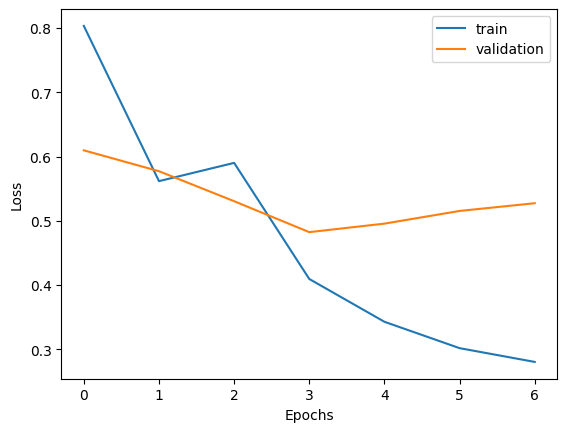

In [ ]:
# Plotting the training/validation loss behavior
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

During the first few epochs, there is a noticeable decrease in training loss, suggesting that the training data is being effectively learned. But after the fourth epoch, the validation loss peaks and then slightly increases after the third epoch, indicating the beginning of overfitting. The model's ability to generalize well was preserved by early stopping at the seventh epoch, which helped avoid overfitting.

# 4. Evaluate the model

Calculating accuracy of the model

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
# Evaluating the model
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

print("Accuracy:", accuracy_score(y_test_classes, y_pred_classes))

129/129 [==============================] - 1s 7ms/step
Accuracy: 0.8304464503537449


After calulating the prediction of the model we can observe that the accuracy of our model is 83 % which is not a bad model, that can perform quite well.

Calculating confusion matrix

In [ ]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test_classes, y_pred_classes))


Confusion Matrix:
 [[ 524   38   63]
 [ 164   54  214]
 [ 125   91 2826]]


#### Generating classification reprot based on the confusion matrix

In [ ]:
print("\nClassification Report:\n", classification_report(y_test_classes, y_pred_classes))


Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.84      0.73       625
           1       0.30      0.12      0.18       432
           2       0.91      0.93      0.92      3042

    accuracy                           0.83      4099
   macro avg       0.62      0.63      0.61      4099
weighted avg       0.81      0.83      0.81      4099



# 5. Result and Prediction

#### Function to predict the input

In [ ]:
"""
    The function predicts the sentiment of a given list of texts.

    Args:
    texts (list of str): A list of text strings for sentiment analysis.
    model (keras Model): A pre-trained TensorFlow/Keras model for sentiment prediction.
    tokenizer (keras Tokenizer): A pre-trained tokenizer for converting text to sequences.
    max_sequence_length (int): The maximum length to which the text sequences will be padded.

    Returns:
    list of str: A list containing the sentiment labels ('Negative', 'Neutral', 'Positive') for each text.
    """

def predict_sentiment(texts, model, tokenizer, max_sequence_length):
    # Clean texts
    texts_clean = [clean_data(text) for text in texts]

    # Convert to sequences and pad
    sequences = tokenizer.texts_to_sequences(texts_clean)
    sequences_padded = pad_sequences(sequences, maxlen=max_sequence_length)

    # Predict sentiments
    predictions = model.predict(sequences_padded)
    sentiments = np.argmax(predictions, axis=1)

    # Map sentiment index to label
    sentiment_labels = []
    for sentiment in sentiments:
        if sentiment == 0:
            sentiment_labels.append("Negative")
        elif sentiment == 1:
            sentiment_labels.append("Neutral")
        else:
            sentiment_labels.append("Positive")

    return sentiment_labels

Checking the review

In [ ]:
texts = ["Bad location and no good food", "Great food but not friendly service", "Very good food and place"] #list of texts
sentiment_labels = predict_sentiment(texts, model, tokens, max_sequence_length) #predicting the sentiment
print(sentiment_labels) #printing the sentiment

1/1 [==============================] - 0s 63ms/step
['Negative', 'Neutral', 'Positive']


Three sample texts are given, each expressing different sentiments. The predict sentiment function is called with the texts, a model, tokenizer, and sequence length. 
The sentiment labels are produced by the function. "Bad location and no parking available" are marked as Negative, "Great food but not friendly service" is labeled as Neutral, "Very good service and food" is labeled as Positive.
